In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier

Loading the Data

In [2]:
train_data = pd.read_csv("../data/train.csv")

print("Training data shape:", train_data.shape)

Training data shape: (594194, 21)


In [3]:
customer_features = train_data.drop(columns=["id", "Churn"])

churn_target = train_data["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [4]:
print("Input shape:", customer_features.shape)
print("\nTarget distribution:")
print(churn_target.value_counts())

Input shape: (594194, 19)

Target distribution:
Churn
0    460377
1    133817
Name: count, dtype: int64


In [5]:
numeric_features = customer_features.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = customer_features.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


Validation Split

In [6]:
X_train, X_valid, y_train, y_valid = train_test_split(
    customer_features,
    churn_target,
    test_size=0.20,
    random_state=31,
    stratify=churn_target
)

In [7]:
print("Training split:", X_train.shape)
print("Validation split:", X_valid.shape)

Training split: (475355, 19)
Validation split: (118839, 19)


Preprocessing

In [8]:
mlp_preprocessor = ColumnTransformer(
    transformers=[
        ("numbers", StandardScaler(), numeric_features),
        (
            "categories",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    sparse_threshold=1.0
)

Neural Network

In [9]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=0.0005,
    batch_size=1024,
    learning_rate_init=0.001,
    max_iter=50,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=6,
    random_state=31,
    verbose=True
)

In [10]:
mlp_pipeline = Pipeline(
    steps=[
        ("preprocessing", mlp_preprocessor),
        ("classifier", mlp_model)
    ]
)

In [11]:
mlp_pipeline.fit(X_train, y_train)

print("MLP training completed.")

Iteration 1, loss = 0.32001473
Validation score: 0.853900
Iteration 2, loss = 0.30812419
Validation score: 0.855520
Iteration 3, loss = 0.30704012
Validation score: 0.855520
Iteration 4, loss = 0.30640872
Validation score: 0.856046
Iteration 5, loss = 0.30582416
Validation score: 0.856383
Iteration 6, loss = 0.30534363
Validation score: 0.855815
Iteration 7, loss = 0.30508976
Validation score: 0.855057
Iteration 8, loss = 0.30469695
Validation score: 0.856340
Iteration 9, loss = 0.30455330
Validation score: 0.855709
Iteration 10, loss = 0.30414181
Validation score: 0.855457
Iteration 11, loss = 0.30403171
Validation score: 0.855730
Iteration 12, loss = 0.30381753
Validation score: 0.856488
Iteration 13, loss = 0.30354891
Validation score: 0.856172
Iteration 14, loss = 0.30352221
Validation score: 0.856151
Iteration 15, loss = 0.30347016
Validation score: 0.856467
Iteration 16, loss = 0.30347443
Validation score: 0.856319
Iteration 17, loss = 0.30332959
Validation score: 0.856193
Iterat

In [12]:
trained_mlp = mlp_pipeline.named_steps["classifier"]

print("Iterations completed:", trained_mlp.n_iter_)
print("Final training loss:", trained_mlp.loss_)

Iterations completed: 19
Final training loss: 0.3030345805513045


In [13]:
print("Best internal validation score:", trained_mlp.best_validation_score_)

Best internal validation score: 0.8564877145742175


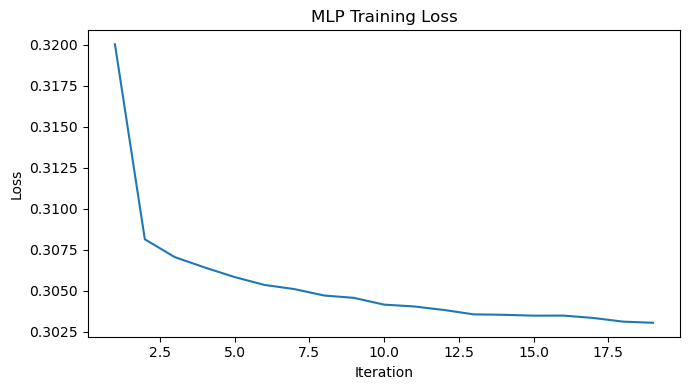

In [14]:
plt.figure(figsize=(7, 4))

iterations = range(1, len(trained_mlp.loss_curve_) + 1)

plt.plot(iterations, trained_mlp.loss_curve_)
plt.title("MLP Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")

plt.tight_layout()
plt.savefig("../screenshots/mlp_training_loss.png", dpi=150)
plt.show()

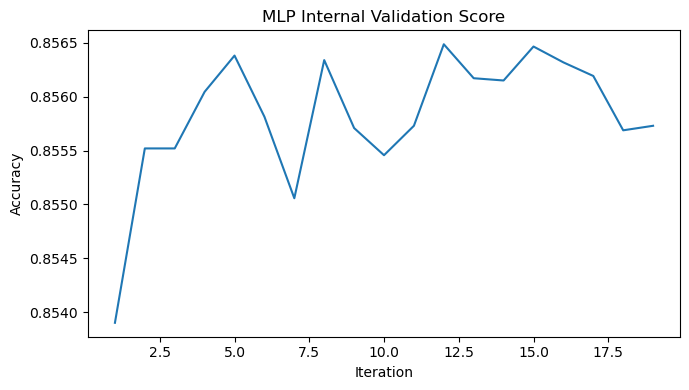

In [15]:
plt.figure(figsize=(7, 4))

iterations = range(1, len(trained_mlp.validation_scores_) + 1)

plt.plot(iterations, trained_mlp.validation_scores_)
plt.title("MLP Internal Validation Score")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.savefig("../screenshots/mlp_internal_validation.png", dpi=150)
plt.show()

Predictions


In [16]:
mlp_predictions = mlp_pipeline.predict(X_valid)

mlp_probabilities = mlp_pipeline.predict_proba(
    X_valid
)[:, 1]

In [17]:
print("Class predictions:", len(mlp_predictions))
print("Probability predictions:", len(mlp_probabilities))
print("Validation rows:", len(X_valid))

Class predictions: 118839
Probability predictions: 118839
Validation rows: 118839


In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

In [19]:
mlp_results = {
    "Accuracy": accuracy_score(y_valid, mlp_predictions),
    "Precision": precision_score(y_valid, mlp_predictions),
    "Recall": recall_score(y_valid, mlp_predictions),
    "F1-score": f1_score(y_valid, mlp_predictions),
    "ROC-AUC": roc_auc_score(y_valid, mlp_probabilities)
}

for metric, value in mlp_results.items():
    print(f"{metric}: {value:.4f}")

Accuracy: 0.8574
Precision: 0.7059
Recall: 0.6285
F1-score: 0.6649
ROC-AUC: 0.9122


In [20]:
print(
    classification_report(
        y_valid,
        mlp_predictions,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.90      0.92      0.91     92076
       Churn       0.71      0.63      0.66     26763

    accuracy                           0.86    118839
   macro avg       0.80      0.78      0.79    118839
weighted avg       0.85      0.86      0.85    118839



In [21]:
mlp_confusion_matrix = confusion_matrix(
    y_valid,
    mlp_predictions
)

print(mlp_confusion_matrix)

[[85068  7008]
 [ 9943 16820]]


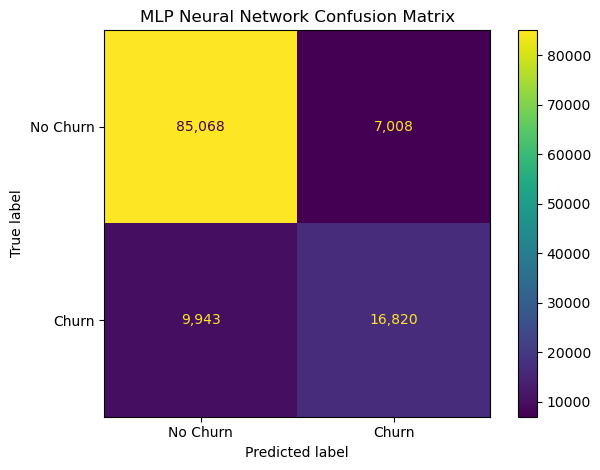

In [22]:
ConfusionMatrixDisplay.from_predictions(
    y_valid,
    mlp_predictions,
    display_labels=["No Churn", "Churn"],
    values_format=","
)

plt.title("MLP Neural Network Confusion Matrix")
plt.tight_layout()
plt.savefig(
    "../screenshots/mlp_confusion_matrix.png",
    dpi=150
)
plt.show()

In [23]:
model_comparison = pd.DataFrame(
    [
        {
            "Accuracy": 0.8546,
            "Precision": 0.6845,
            "Recall": 0.6576,
            "F1-score": 0.6708,
            "ROC-AUC": 0.9082
        },
        {
            "Accuracy": 0.8075,
            "Precision": 0.5447,
            "Recall": 0.8835,
            "F1-score": 0.6739,
            "ROC-AUC": 0.9081
        },
        {
            "Accuracy": 0.8577,
            "Precision": 0.7002,
            "Recall": 0.6435,
            "F1-score": 0.6707,
            "ROC-AUC": 0.9123
        },
        {
            "Accuracy": 0.8605,
            "Precision": 0.7099,
            "Recall": 0.6436,
            "F1-score": 0.6751,
            "ROC-AUC": 0.9156
        },
        mlp_results
    ],
    index=[
        "Logistic Regression",
        "Weighted Logistic Regression",
        "Random Forest",
        "XGBoost",
        "MLP Neural Network"
    ]
)

model_comparison.round(4)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.8546,0.6845,0.6576,0.6708,0.9082
Weighted Logistic Regression,0.8075,0.5447,0.8835,0.6739,0.9081
Random Forest,0.8577,0.7002,0.6435,0.6707,0.9123
XGBoost,0.8605,0.7099,0.6436,0.6751,0.9156
MLP Neural Network,0.8574,0.7059,0.6285,0.6649,0.9122


In [24]:
model_comparison.to_csv(
    "../report/full_model_comparison.csv"
)